### PH464/564: Scientific Computing II
***J.S. Hazboun***

___

# Homework 2
### Due: Monday, Oct 13th at 11:59pm Pacific
---

# Week 2 HW

The purpose of this assignment is to get comfortable working with a few of the tools we'll be using throughout the course (e.g., git, jupyter notebooks, pandas, matplotlib), and to do some basic data exploration and statistics.

Data sets (in the `data` directory):

[US Births 2000-2014](https://raw.githubusercontent.com/fivethirtyeight/data/master/births/US_births_2000-2014_SSA.csv)

[TMDB Movie Dataset](https://www.kaggle.com/tmdb/tmdb-movie-metadata/data)

NOTE: The TMDB data is hosted on kaggle.  See the host page for details on the data. There are two separate data sets from TMDB, one for movie details and one for credits.  These files include some data in JSON format; see [here](https://www.kaggle.com/sohier/getting-imdb-kernels-working-with-tmdb-data/) for tips on reading the data.

## Problem 1



Find an interesting feature in the US Birth data set that we didn't find in class.  Be sure to describe clearly the feature you found, and include figures to back it up.

### Solution

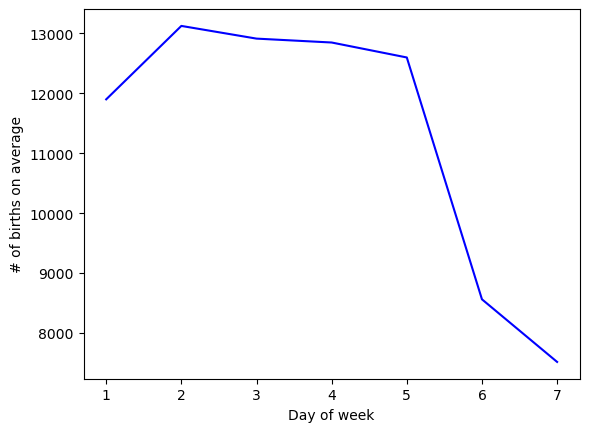

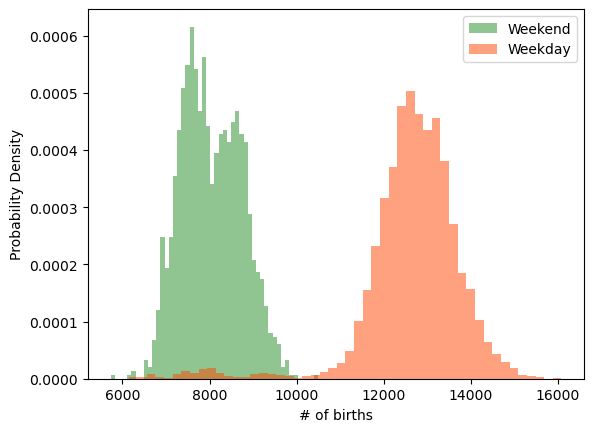

In [100]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Import data set
births = pd.read_csv('https://raw.githubusercontent.com/fivethirtyeight/data/master/births/US_births_2000-2014_SSA.csv')
births

byweekday = births.groupby('day_of_week') # Sort data into days of the week
births_per_weekday = byweekday.mean()

# Visualize data trend by day of week
plt.plot(births_per_weekday.index, births_per_weekday.births, color='blue')
plt.ylabel('# of births on average')
plt.xlabel('Day of week')
plt.show()
# Interesting, let's explore a bit deeper

# Extract the weekend data points
saturday = births['day_of_week'] == 6
sunday = births['day_of_week'] == 7

plt.hist(births[saturday | sunday]['births'], density=True, alpha=0.5, bins=50, label='Weekend', color='forestgreen') # plot the data on the weekend
plt.hist(births[~saturday & ~sunday]['births'], density=True, alpha=0.5, bins=50, label='Weekday', color='orangered') # plot the data on weekdays
plt.xlabel('# of births')
plt.ylabel('Probability Density')
plt.legend();

## Problem 2

In class we found that the total number of births roughly correlated with the rise of the housing bubble and subsequent great recession.  We also found that people were generally superstitious, having fewer babies on Friday the 13th compared to other weekdays.  Does the level of superstition change with the health of the US economy?

~**564 students**: find some actual public data on the health of the US economy and see if a particular metric tracks with the annual birth rate in the US.~

### Solution

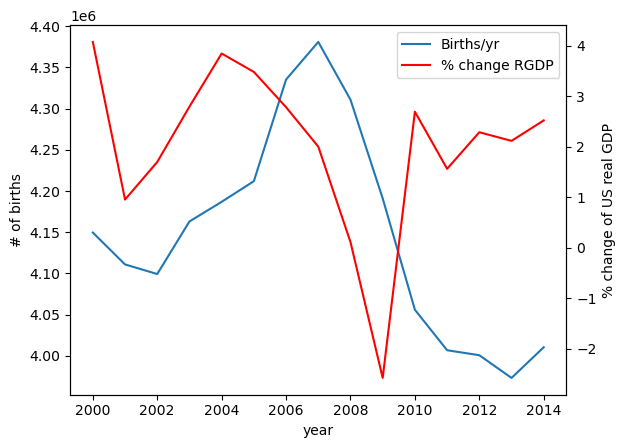

In [101]:
# Continuing from above
# Sort our data by year this time
byyear = births.groupby('year')
births_per_year = byyear.sum()

# Grab the data on the US's Real GDP, which is inflation-adjusted GDP
econhealth = pd.read_csv('GDPC1_PCH.csv')

# Plot them against each other
fig, ax1 = plt.subplots()

ax1.set_xlabel('year')
ax1.set_ylabel('# of births')
ax1.plot(births_per_year.index, births_per_year.births, label='Births/yr')

ax2 = ax1.twinx()

ax2.set_ylabel('% change of US real GDP')
ax2.plot(econhealth.observation_date, econhealth.GDPC1_PCH, color='Red', label='% change RGDP')

# Combine graphs on legend
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

handles = handles1 + handles2
labels = labels1 + labels2

ax1.legend(handles, labels)
plt.show()

# Source: https://fred.stlouisfed.org/series/GDPC1#

## Problem 3

Download and parse the TMDB data.  Find an interesting feature in the data.  Be sure to describe clearly the feature you found, and include figures to back it up.

### Solution

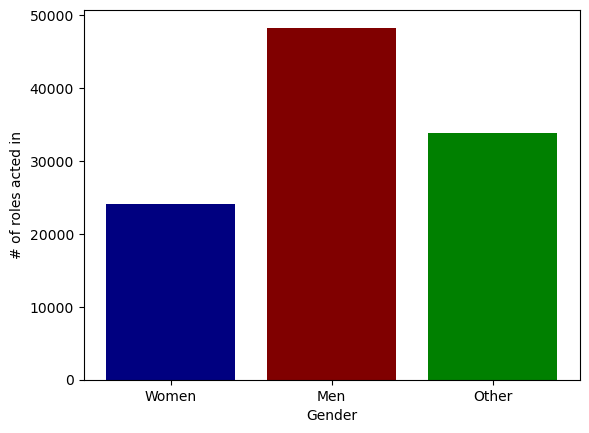

In [102]:
import json

# Import the data we want
tmdb = pd.read_csv('tmdb_5000_credits_provided.csv')
cast = tmdb['cast']

indexint = np.arange(0,4803)
indexstr = pd.Index(list(indexint))    
cast.index = indexstr  # Index the data

men = 0
women = 0
other = 0

# Go through each movie, pulling the genders of all actors
for i in range(0,4803):
    movie = cast.loc[i]
    movielist = json.loads(movie)
    genders = [act['gender'] for act in movielist]
    
    # Sort each actor by gender for a given movie
    for j in range(0,len(genders)):
        if genders[j] == 1:
            women += 1
        elif genders[j] == 2:
            men += 1
        else:
            other += 1

whichgenders = ['Women','Men','Other']
numbergenders = [women, men, other]

# Plot it
plt.bar(whichgenders, numbergenders, color=['navy','maroon','green']);
plt.xlabel('Gender');
plt.ylabel('# of roles acted in');